In [1]:
%pip install rasterio numpy matplotlib -q
print('Installed succesfully!')

Installed succesfully!


In [3]:
import os
from google.colab import drive
drive.mount('/content/drive')


SHARED_FOLDER_ID = '1T7uRYN0Ek6H-HEdjIqgXVq_FarJ_hrJk'



BASE = f'/content/drive/.shortcut-targets-by-id/{SHARED_FOLDER_ID}/DAT103_Indonesia_Project'

Mounted at /content/drive


In [4]:
# checking path correctness
if os.path.exists(BASE):
    print("Connected to shared Drive!")
    print(os.listdir(BASE))
else:
    print("Shared folder not found. Check your SHARED_FOLDER_ID or folder name.")
    raise FileNotFoundError(f"Path not found: {BASE}")

Connected to shared Drive!
['data', 'models', 'figures']


In [5]:

import os



# AOI Bounding Box (~50 km²)
AOI_BBOX = {
    'min_lon': 107.2831,
    'max_lon': 107.3471,
    'min_lat': -6.7023,
    'max_lat': -6.6383
}

# Shared folder paths
LANDSAT_DIR   = f'{BASE}/data/landsat/'
LULC_DIR      = f'{BASE}/data/lulc/'
PROCESSED_DIR = f'{BASE}/data/processed/'
PATCHES_DIR   = f'{BASE}/data/patches/'
MODELS_DIR    = f'{BASE}/models/'
FIGURES_DIR   = f'{BASE}/figures/'

# creating folders if they dont exist
for d in [LANDSAT_DIR, LULC_DIR, PROCESSED_DIR, PATCHES_DIR, MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print('Shared Drive folder structure ready!')
print(f'   Base path : {BASE}')
print(f'   AOI lon   : [{AOI_BBOX["min_lon"]}, {AOI_BBOX["max_lon"]}]')
print(f'   AOI lat   : [{AOI_BBOX["min_lat"]}, {AOI_BBOX["max_lat"]}]')

Shared Drive folder structure ready!
   Base path : /content/drive/.shortcut-targets-by-id/1T7uRYN0Ek6H-HEdjIqgXVq_FarJ_hrJk/DAT103_Indonesia_Project
   AOI lon   : [107.2831, 107.3471]
   AOI lat   : [-6.7023, -6.6383]


In [6]:
os.listdir(LANDSAT_DIR)

['LC08_L2SP_122064_20241010_20241015_02_T1_MTL.txt',
 'LC08_L2SP_122064_20241010_20241015_02_T1_SR_B2.TIF',
 'LC08_L2SP_122064_20241010_20241015_02_T1_SR_B3.TIF',
 'LC08_L2SP_122064_20241010_20241015_02_T1_SR_B4.TIF',
 'LC08_L2SP_122064_20241010_20241015_02_T1_SR_B5.TIF',
 'LC08_L2SP_122064_20241010_20241015_02_T1_SR_B6.TIF',
 'LC08_L2SP_122064_20241010_20241015_02_T1_SR_B7.TIF',
 'scene_metadata.json']

In [7]:
import rasterio, numpy as np, glob

b4_path = glob.glob(f"{LANDSAT_DIR}/*_B4.TIF")[0]
b5_path = glob.glob(f"{LANDSAT_DIR}/*_B5.TIF")[0]

with rasterio.open(b4_path) as src:
    red_raw = src.read(1).astype(float)
    red_nodata = src.nodata
    profile = src.profile

with rasterio.open(b5_path) as src:
    nir_raw = src.read(1).astype(float)
    nir_nodata = src.nodata

print(f"Band 4 shape: {red_raw.shape}")
print(f"Band 5 shape: {nir_raw.shape}")

Band 4 shape: (237, 237)
Band 5 shape: (237, 237)


In [8]:
# IMPORTANT: Landsat Collection 2 Level-2 surface reflectance scale
# reflectance = raw_value * 0.0000275 -.2
red = red_raw * 0.0000275 - 0.2
nir = nir_raw * 0.0000275 - 0.2

# Mask invalid pixels
valid_mask = (red_raw > 0) & (red_raw < 65535) & (nir_raw > 0) & (nir_raw < 65535)
red[~valid_mask] = np.nan
nir[~valid_mask] = np.nan

print(f"Reflectance range — Red: [{np.nanmin(red):.3f}, {np.nanmax(red):.3f}]")
print(f"Reflectance range — NIR: [{np.nanmin(nir):.3f}, {np.nanmax(nir):.3f}]")

Reflectance range — Red: [-0.038, 0.733]
Reflectance range — NIR: [0.030, 0.835]


In [9]:
# NDVI = (NIR - Red) / (NIR + Red)
ndvi = (nir - red) / (nir + red + 1e-10)
ndvi = np.clip(ndvi, -1, 1)
ndvi[~valid_mask] = np.nan

print(f"NDVI range: [{np.nanmin(ndvi):.3f}, {np.nanmax(ndvi):.3f}]")
print(f"Mean NDVI: {np.nanmean(ndvi):.3f}")
print(f"% pixels > 0.5 (Dense+): {100 * np.sum(ndvi > 0.5) / np.sum(valid_mask):.1f}%")
print(f"% pixels < 0.1 (Bare/Water): {100 * np.sum(ndvi < 0.1) / np.sum(valid_mask):.1f}%")

NDVI range: [-0.031, 1.000]
Mean NDVI: 0.623
% pixels > 0.5 (Dense+): 79.6%
% pixels < 0.1 (Bare/Water): 0.9%


In [10]:

ndvi_path = f"{PROCESSED_DIR}/ndvi.tif"
ndvi_profile = profile.copy()
ndvi_profile.update(dtype=rasterio.float32, count=1, nodata=-9999.0)
ndvi_filled = np.where(np.isnan(ndvi), -9999.0, ndvi)

with rasterio.open(ndvi_path, 'w', **ndvi_profile) as dst:
    dst.write(ndvi_filled.astype(np.float32), 1)

print(f"NDVI saved to: {ndvi_path}")

NDVI saved to: /content/drive/.shortcut-targets-by-id/1T7uRYN0Ek6H-HEdjIqgXVq_FarJ_hrJk/DAT103_Indonesia_Project/data/processed//ndvi.tif


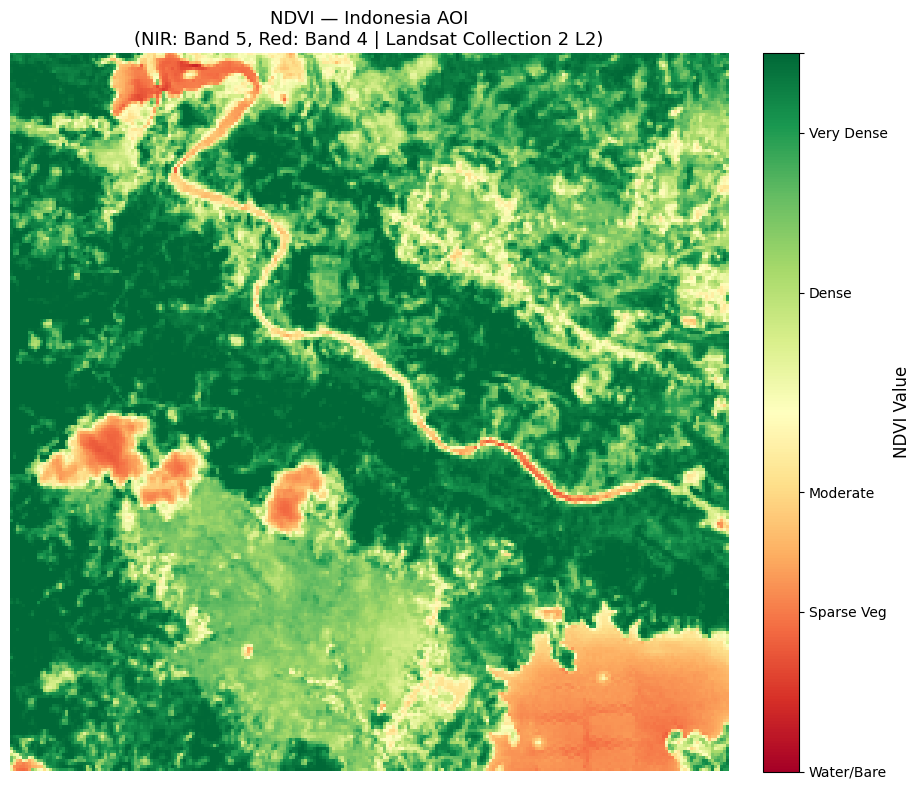

Saved ndvi_map.png


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(ndvi, cmap='RdYlGn', vmin=-0.1, vmax=0.8)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('NDVI Value', fontsize=12)
cbar.set_ticks([-0.1, 0.1, 0.25, 0.5, 0.7, 0.8])
cbar.set_ticklabels(['Water/Bare', 'Sparse Veg', 'Moderate', 'Dense', 'Very Dense', ''])

ax.set_title("NDVI — Indonesia AOI\n(NIR: Band 5, Red: Band 4 | Landsat Collection 2 L2)", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/ndvi_map.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved ndvi_map.png")